In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"syedsarmasthhussain","key":"f95ff840d058c492e025ea7ad2468c0a"}'}

In [ ]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot

Dataset URL: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
License(s): CC-BY-NC-SA-4.0


In [ ]:
!unzip /content/edgeiiotset-cyber-security-dataset-of-iot-iiot.zip

Archive:  /content/edgeiiotset-cyber-security-dataset-of-iot-iiot.zip
  inflating: Edge-IIoTset dataset/Attack traffic/Backdoor_attack.csv  
  inflating: Edge-IIoTset dataset/Attack traffic/Backdoor_attack.pcap  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS HTTP Flood Attacks.pcap  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS ICMP Flood Attacks.pcap  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS TCP SYN Flood Attacks.pcap  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS UDP Flood Attacks.pcap  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS_HTTP_Flood_attack.csv  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS_ICMP_Flood_attack.csv  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS_TCP_SYN_Flood_attack.csv  
  inflating: Edge-IIoTset dataset/Attack traffic/DDoS_UDP_Flood_attack.csv  
  inflating: Edge-IIoTset dataset/Attack traffic/MITM (ARP spoofing + DNS) Attack.pcap  
  inflating: Edge-IIoTset dataset/Attack traffic/MITM_attack.c

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
file_path = "/content/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"

In [ ]:
df = pd.read_csv(file_path)

<ipython-input-15-47c250c455f0>:1: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:
df.columns

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len

In [ ]:
if 'Attack_type' in df.columns:
    print(df['Attack_type'].unique())

['Normal' 'MITM' 'Uploading' 'Ransomware' 'SQL_injection' 'DDoS_HTTP'
 'DDoS_TCP' 'Password' 'Port_Scanning' 'Vulnerability_scanner' 'Backdoor'
 'XSS' 'Fingerprinting' 'DDoS_UDP' 'DDoS_ICMP']


In [ ]:
df['Attack_type'].value_counts()

,count
Attack_type,
Normal,1615643
DDoS_UDP,121568
DDoS_ICMP,116436
SQL_injection,51203
Password,50153
Vulnerability_scanner,50110
DDoS_TCP,50062
DDoS_HTTP,49911
Uploading,37634


Install & Import Required Libraries

In [ ]:
# Install missing libraries
!pip install -q pandas scikit-learn matplotlib seaborn tensorflow

# Import all essential libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

Load the Dataset

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv')  # Replace with actual filename

# View shape and sample data
print("Shape of dataset:", df.shape)
df.head()

<ipython-input-20-ddbb28175335>:2: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv')  # Replace with actual filename


Shape of dataset: (2219201, 63)


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


Drop Unnecessary Columns

In [ ]:
# Drop columns that are not useful for ANN model
columns_to_drop = [
    'frame.time', 'ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4',
    'http.request.uri.query', 'http.referer', 'http.request.full_uri', 'mqtt.topic',
    'mqtt.msg', 'mqtt.msg_decoded_as', 'mqtt.protoname', 'dns.qry.name',
    'Attack_label'  # We'll use 'Attack_type' instead
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

Handle Missing Values

In [ ]:
# Check and handle missing values
df.replace('?', np.nan, inplace=True)
df.fillna(0, inplace=True)  # You can also choose mean/mode if preferred

# ✅ Confirm cleanup
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


Encode Categorical Columns

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Attack_type')  # Exclude target label for now

In [ ]:
# 🎯 Encode categorical features (safe handling of mixed types)
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str)  # Convert to string first
    df[col] = le.fit_transform(df[col])

In [ ]:
# 🎯 Encode target labels
df['Attack_type'] = le.fit_transform(df['Attack_type'])
target_names = le.classes_  # Useful for inverse mapping later

Feature Scaling & Splitting

In [ ]:
# Separate features and target
X = df.drop(columns=['Attack_type'])
y = df['Attack_type']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 🎯 One-hot encode labels for ANN
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1775360
Testing samples: 443841


Step 1: Define ANN Architecture

In [ ]:
# Step 1: Define the ANN architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define model structure
model = Sequential()

# Input layer and first hidden layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))  # Dropout for regularization

# Second hidden layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# Output layer (multi-class softmax)
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

# ✅ Summary of model structure
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,503 (60.56 KB)

 Trainable params: 15,503 (60.56 KB)

 Non-trainable params: 0 (0.00 B)

Step 2: Compile the Model

In [ ]:
# Step 2: Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Step 3: Train the Model

In [ ]:
# Step 3: Train the model
history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step - accuracy: 0.9474 - loss: 0.1668 - val_accuracy: 0.9905 - val_loss: 0.0277
Epoch 2/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 84s 5ms/step - accuracy: 0.9876 - loss: 0.0379 - val_accuracy: 0.9920 - val_loss: 0.0227
Epoch 3/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 78s 4ms/step - accuracy: 0.9902 - loss: 0.0299 - val_accuracy: 0.9948 - val_loss: 0.0168
Epoch 4/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - accuracy: 0.9913 - loss: 0.0259 - val_accuracy: 0.9948 - val_loss: 0.0156
Epoch 5/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - accuracy: 0.9917 - loss: 0.0246 - val_accuracy: 0.9950 - val_loss: 0.0153
Epoch 6/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.9923 - loss: 0.0227 - val_accuracy: 0.9954 - val_loss: 0.0140
Epoch 7/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - accuracy: 0.9924 - loss: 0.0222 - val_accuracy: 0.9954 - val_loss: 0.0134
Epoch 8/20
11096/11096 ━━━━━━━━━━━━━━━━━━━━ 81s 4ms/step - accuracy: 

Step 4: Evaluate the Model

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")

13871/13871 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.9957 - loss: 0.0329

✅ Test Accuracy: 99.59%


Step 5: Plot Accuracy and Loss

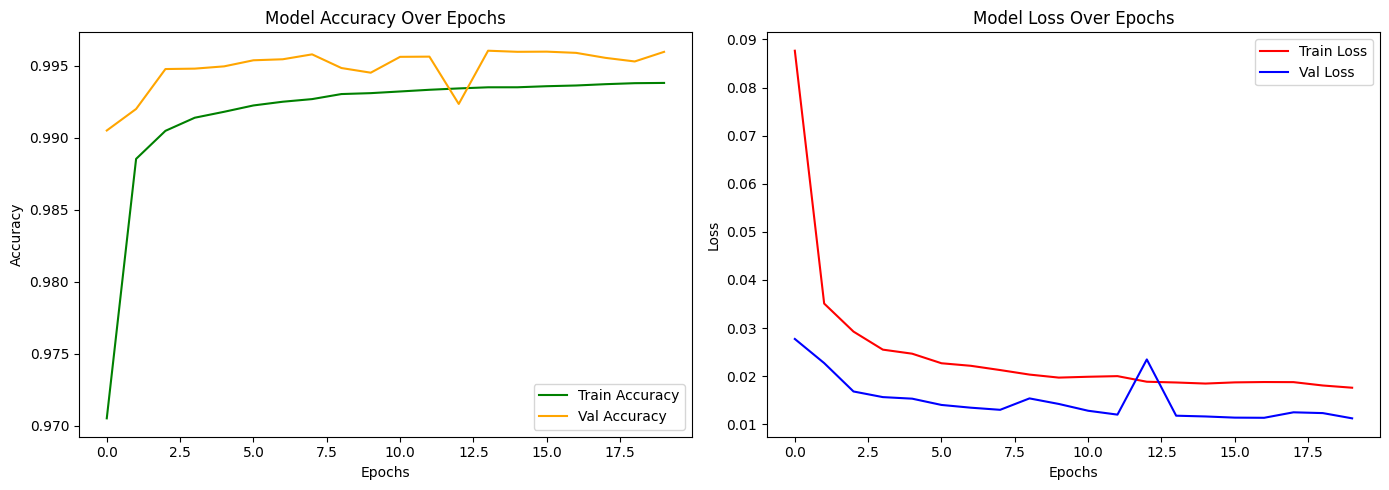

In [ ]:
# Plot training & validation accuracy/loss
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='blue')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report & Confusion Matrix

13871/13871 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      4891
           1       1.00      0.99      0.99     10117
           2       1.00      1.00      1.00     23171
           3       1.00      0.93      0.96     10079
           4       1.00      1.00      1.00     24323
           5       0.93      0.27      0.42       182
           6       1.00      1.00      1.00       263
           7       1.00      1.00      1.00    323305
           8       0.99      0.98      0.99      9971
           9       0.81      1.00      0.89      4514
          10       1.00      0.90      0.95      2160
          11       0.98      1.00      0.99     10100
          12       0.98      0.98      0.98      7651
          13       1.00      1.00      1.00      9941
          14       0.95      0.98      0.97      3173

    accuracy                           1.00    443841
   macro

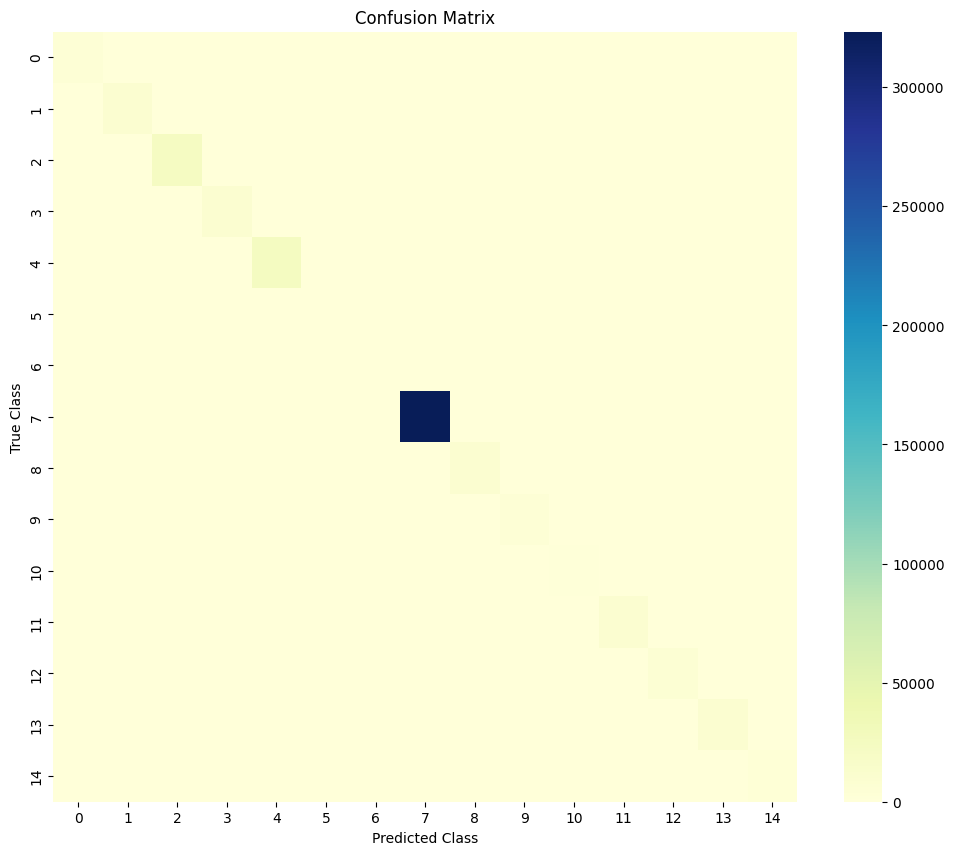

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred_classes))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=False, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

Part B: Code Block — Random Label Flipping Attack

In [ ]:
import random
import copy

# 🎯 Targeted label poisoning: Flip ONLY attack labels to "Normal"
def targeted_poison_labels(y_train_original, normal_label, flip_percent):
    y_poisoned = copy.deepcopy(y_train_original)
    n_total = len(y_poisoned)

    # Indices of only attack labels (i.e., label != Normal)
    attack_indices = [i for i, label in enumerate(y_poisoned) if label != normal_label]
    n_attack = len(attack_indices)
    n_flip = int(n_attack * (flip_percent / 100))

    indices_to_flip = random.sample(attack_indices, n_flip)

    for idx in indices_to_flip:
        y_poisoned[idx] = normal_label

    return y_poisoned

Part B: Training & Evaluating with Poisoned Labels

In [ ]:
# Run model training on targeted poisoned labels
targeted_accuracy_results = []
flip_levels = [0, 5, 10, 15, 20, 25, 30]

# Identify which encoded label represents "Normal"
normal_label = y.value_counts().idxmax()  # assumes "Normal" is the most frequent

for flip_pct in flip_levels:
    print(f"\n🎯 Training with {flip_pct}% targeted poisoned labels...")

    # Poison only attack labels → set to "Normal"
    y_poisoned = targeted_poison_labels(list(y_train), normal_label, flip_pct)
    y_poisoned_cat = to_categorical(y_poisoned)

    # Rebuild & compile model
    model_poisoned = Sequential()
    model_poisoned.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
    model_poisoned.add(Dropout(0.3))
    model_poisoned.add(Dense(64, activation='relu'))
    model_poisoned.add(Dropout(0.2))
    model_poisoned.add(Dense(y_poisoned_cat.shape[1], activation='softmax'))
    model_poisoned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train model silently
    model_poisoned.fit(X_train, y_poisoned_cat, epochs=10, batch_size=128, verbose=0)

    # Evaluate
    test_loss, test_acc = model_poisoned.evaluate(X_test, y_test_cat, verbose=0)
    targeted_accuracy_results.append(test_acc * 100)
    print(f"✅ Accuracy with {flip_pct}% targeted poisoned labels: {test_acc * 100:.2f}%")



🎯 Training with 0% targeted poisoned labels...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Accuracy with 0% targeted poisoned labels: 99.55%

🎯 Training with 5% targeted poisoned labels...
✅ Accuracy with 5% targeted poisoned labels: 99.54%

🎯 Training with 10% targeted poisoned labels...
✅ Accuracy with 10% targeted poisoned labels: 99.59%

🎯 Training with 15% targeted poisoned labels...
✅ Accuracy with 15% targeted poisoned labels: 99.54%

🎯 Training with 20% targeted poisoned labels...
✅ Accuracy with 20% targeted poisoned labels: 99.55%

🎯 Training with 25% targeted poisoned labels...
✅ Accuracy with 25% targeted poisoned labels: 99.48%

🎯 Training with 30% targeted poisoned labels...
✅ Accuracy with 30% targeted poisoned labels: 99.46%


📉 Plotting the Degradation

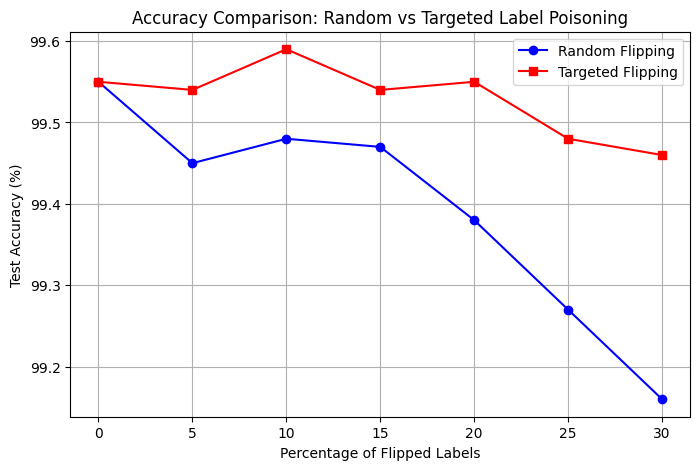

In [ ]:
# Manually set your random accuracy results
accuracy_results = [99.55, 99.45, 99.48, 99.47, 99.38, 99.27, 99.16]
targeted_accuracy_results = [99.55, 99.54, 99.59, 99.54, 99.55, 99.48, 99.46]
flip_levels = [0, 5, 10, 15, 20, 25, 30]

# Plot both strategies
plt.figure(figsize=(8, 5))
plt.plot(flip_levels, accuracy_results, marker='o', label='Random Flipping', color='blue')
plt.plot(flip_levels, targeted_accuracy_results, marker='s', label='Targeted Flipping', color='red')
plt.title("Accuracy Comparison: Random vs Targeted Label Poisoning")
plt.xlabel("Percentage of Flipped Labels")
plt.ylabel("Test Accuracy (%)")
plt.grid(True)
plt.legend()
plt.show()